# Telco Customer Churn Analysis

This project looks at customer churn in a telecom dataset.

The first step is to inspect the raw data and check its structure, missing values, duplicates, data types, and possible outliers before making any changes.

## 1. Setup and Data Loading

The required libraries are imported first, followed by the raw customer dataset.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("./dataset/telco_customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

The dataset contains customer-level records with 7043 rows and 21 columns.

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

The initial missing-value check shows no NaN values. I will also check for blank or whitespace-only values because they may not be detected by isnull().

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
(df.astype(str).apply(lambda col: col.str.strip().eq("").sum()))

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

There are no duplicate rows in the dataset.

In [10]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [11]:
df['Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [12]:
df['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

In [13]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [14]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [15]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [16]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [17]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [18]:
df['OnlineSecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [19]:
df['TechSupport'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

### Checking TotalCharges

TotalCharges contains values that look numeric but is stored as an object column. I will check whether all values can be converted to numeric values.

In [20]:
display(df["TotalCharges"].head())
display(df["TotalCharges"].unique())

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [21]:
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

total_charges_numeric.isnull().sum()

np.int64(11)

In [22]:
df.loc[total_charges_numeric.isnull(), ["customerID", "tenure", "TotalCharges"]]

,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


The TotalCharges column contains blank values that were not detected by the initial isnull() check because they were stored as strings. These values occur for customers with zero tenure.

In [23]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [24]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### Checking for numerical outliers

I will use the IQR method to identify unusually low or high values in the numerical columns.

In [25]:
numeric_columns = ["tenure", "MonthlyCharges"]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"{column}:")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")
    print()

tenure:
Lower bound: -60.00
Upper bound: 124.00
Number of outliers: 0

MonthlyCharges:
Lower bound: -46.02
Upper bound: 171.38
Number of outliers: 0



The IQR method identifies values that are outside the usual range. These values will not be removed at this stage because they may represent genuine customers rather than data errors.

## Audit Summary

The dataset contains 7,043 customer records and 21 columns.

The initial missing-value check showed no standard NaN values. A separate check for blank values was also performed to identify values that may not be recognised by isnull().

The duplicate check was performed using the full dataset.

The main data type issue found was TotalCharges, which is stored as an object even though it contains numeric-looking values. This column was checked using numeric conversion to identify values that could not be converted.

The numerical columns were also checked for potential outliers using the IQR method. The identified values were kept in the raw dataset because an unusual value does not automatically mean that the record is incorrect.

No cleaning or feature engineering was performed during this audit stage.

## 2. Data Cleaning and Preprocessing

The raw data has been audited, so the next step is to fix the issues found during the audit and prepare the data for the later analysis and modelling stages.

In [26]:
df_clean = df.copy()

In [27]:
df_clean.shape

(7043, 21)

In [28]:
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

In [29]:
df_clean["TotalCharges"]

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [30]:
df_clean["TotalCharges"].dtype

dtype('float64')

In [31]:
df_clean["TotalCharges"].isnull().sum()

np.int64(11)

In [32]:
df_clean[df_clean["TotalCharges"].isnull()][
    ["customerID", "tenure", "TotalCharges"]
]

,customerID,tenure,TotalCharges
488,4472-LVYGI,0,NaN
753,3115-CZMZD,0,NaN
936,5709-LVOEQ,0,NaN
1082,4367-NUYAO,0,NaN
1340,1371-DWPAZ,0,NaN
3331,7644-OMVMY,0,NaN
3826,3213-VVOLG,0,NaN
4380,2520-SGTTA,0,NaN
5218,2923-ARZLG,0,NaN
6670,4075-WKNIU,0,NaN


In [33]:
df_clean.loc[df_clean["TotalCharges"].isnull(), "tenure"].value_counts()

tenure
0    11
Name: count, dtype: int64

### TotalCharges

The `TotalCharges` column was originally stored as an object even though it represents a numerical value. After converting it to numeric, the blank values were represented as missing values.

The affected records were checked against `tenure` to understand why the values were missing before deciding how to handle them.

### 2.1 Handling missing TotalCharges

In [34]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [35]:
df_clean["TotalCharges"].isnull().sum()

np.int64(0)

### 2.2 Checking missing values

In [36]:
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 2.3 Separating features and target

In [37]:
X = df_clean.drop(columns=["Churn", "customerID"])
y = df_clean["Churn"]

In [38]:
X.shape

(7043, 19)

In [39]:
y.shape

(7043,)

In [40]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [41]:
y.value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [42]:
y = y.map({"Yes": 1, "No": 0})

In [43]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### 2.4 Train/test split

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
X_train.shape

(5634, 19)

In [47]:
X_test.shape

(1409, 19)

In [48]:
y_train.value_counts(normalize=True)

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [49]:
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

### 2.5 Identifying numerical and categorical columns

In [50]:
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns

In [51]:
categorical_features = X_train.select_dtypes(include=["object"]).columns

In [52]:
display(numerical_features)
display(categorical_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

### 2.6 Building the preprocessing steps

In [53]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [54]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [55]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

### 2.7 Fitting preprocessing on the training data

In [57]:
X_train_processed = preprocessor.fit_transform(X_train)

In [58]:
X_test_processed = preprocessor.transform(X_test)

In [59]:
X_train_processed.shape

(5634, 45)

In [60]:
X_test_processed.shape

(1409, 45)

In [61]:
y_train.shape

(5634,)

In [62]:
y_test.shape

(1409,)

### 2.8 Preprocessing summary

The cleaned dataset was split into training and test sets before preprocessing. Numerical variables were handled using median imputation and standard scaling, while categorical variables were handled using most-frequent imputation and one-hot encoding. The preprocessing steps were fitted only on the training data and then applied to the test data to avoid data leakage.

### Avoiding data leakage

The train/test split was performed before fitting the preprocessing transformers. Imputation, encoding, and scaling were learned from the training data only. The same fitted transformations were then applied to the test data.

## 3. Exploratory Data Analysis

The data has been cleaned and prepared, so the next step is to look at the customer data and understand the main patterns behind churn.

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
sns.set_theme()

In [65]:
df_clean.shape

(7043, 21)

In [66]:
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [67]:
df_clean.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

### 3.1 Churn distribution

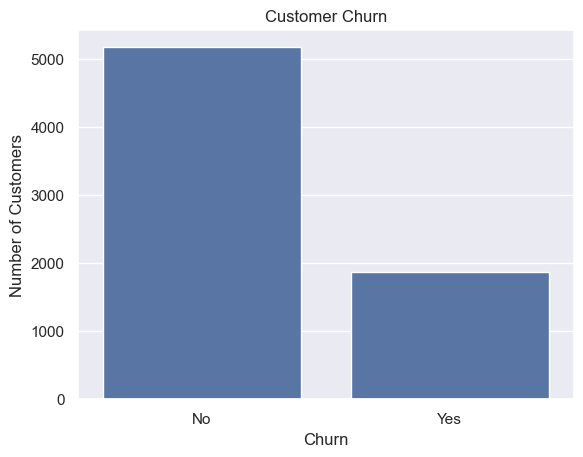

In [68]:
sns.countplot(data=df_clean, x="Churn")
plt.title("Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.savefig("images/1_customer_churn.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** The number of customers who stayed is higher than the number who churned.

### 3.2 Tenure distribution

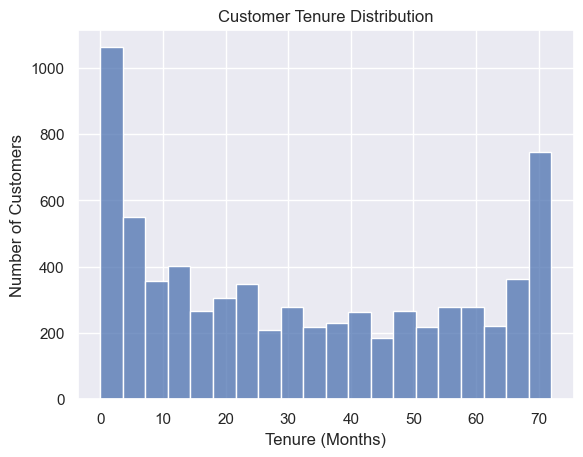

In [69]:
sns.histplot(data=df_clean, x="tenure", bins=20)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.savefig("images/2_customer_tenure.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.3 Monthly charges distribution

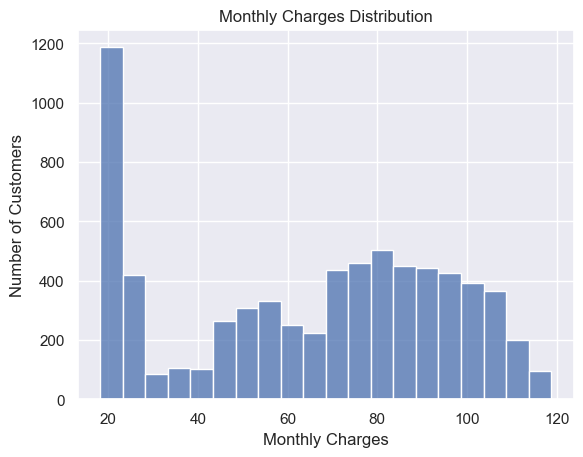

In [70]:
sns.histplot(data=df_clean, x="MonthlyCharges", bins=20)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.savefig("images/3_monthly_charges.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.4 Total charges distribution

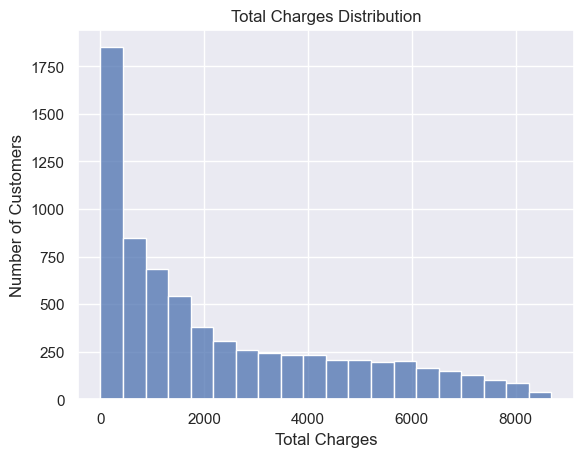

In [71]:
sns.histplot(data=df_clean, x="TotalCharges", bins=20)
plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.savefig("images/4_total_charges.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.5 Contract Distribution

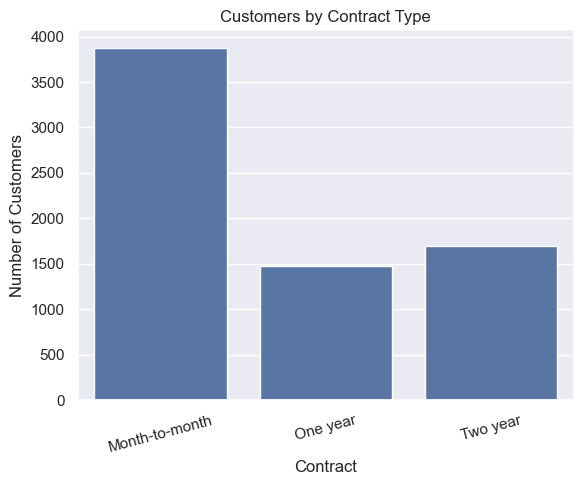

In [72]:
sns.countplot(data=df_clean, x="Contract")
plt.title("Customers by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.savefig("images/5_contract_type.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.6 Churn By Contract Type

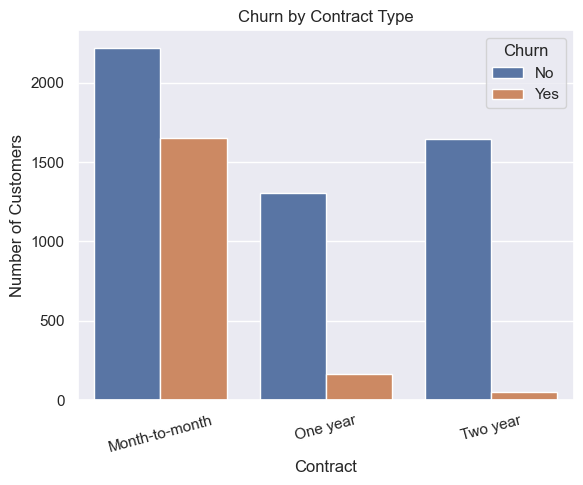

In [73]:
sns.countplot(data=df_clean, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.savefig("images/6_churn_by_contract_type.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.7 Churn Rate By Contract Type

In [74]:
contract_churn_rate = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
)
contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


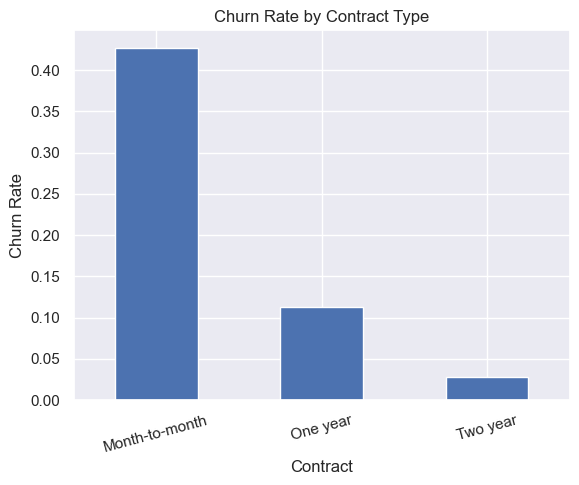

In [75]:
contract_churn_rate["Yes"].plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate")
plt.xticks(rotation=15)
plt.savefig("images/7_churn_rate_by_contract_type.png", dpi=300, bbox_inches="tight")
plt.show()

**Business insight:** Month-to-month customers have the highest churn rate at about 42.7%, compared with 11.3% for one-year contracts and 2.8% for two-year contracts. This suggests that month-to-month customers may need more attention from the retention team.

### 3.8 Churn By Tenure Group

In [76]:
df_clean["tenure_group"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

In [77]:
tenure_churn_rate = pd.crosstab(
    df_clean["tenure_group"],
    df_clean["Churn"],
    normalize="index"
)
tenure_churn_rate

Churn,No,Yes
tenure_group,,
0-12,0.525618,0.474382
13-24,0.712891,0.287109
25-48,0.796110,0.203890
49-72,0.904868,0.095132


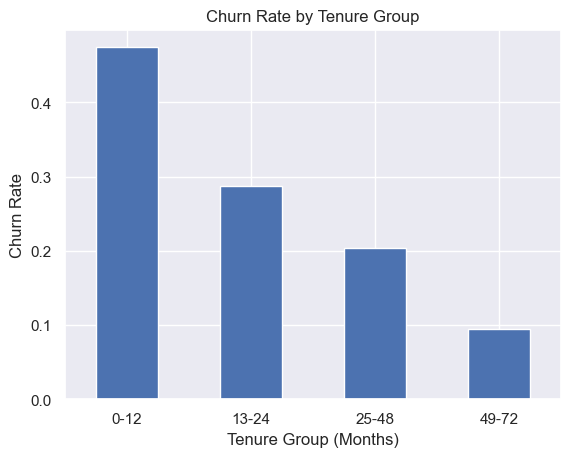

In [78]:
tenure_churn_rate["Yes"].plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.savefig("images/8_churn_rate_by_tenure_group.png", dpi=300, bbox_inches="tight")
plt.show()

**Business insight:** Customers with 0-12 months of tenure have the highest churn rate at about 47.4%. Churn decreases as tenure increases, which suggests that the early customer experience may be an important part of retention.

### 3.9 Churn By Internet Service

In [79]:
internet_churn_rate = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
)
internet_churn_rate

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


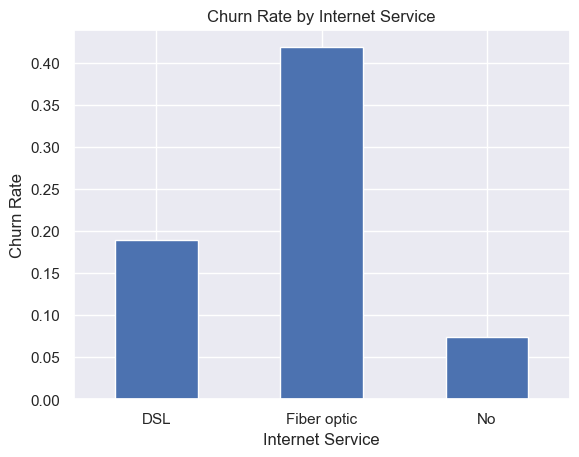

In [80]:
internet_churn_rate["Yes"].plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.savefig("images/9_churn_rate_by_internet_service.png", dpi=300, bbox_inches="tight")
plt.show()

**Business insight:** Fiber optic customers have the highest churn rate at about 41.9%, compared with 19.0% for DSL and 7.4% for customers without internet service. This may indicate that the experience associated with fiber optic service deserves closer attention.

### 3.10 Tech Support & Churn

In [81]:
tech_support_churn_rate = pd.crosstab(
    df_clean["TechSupport"],
    df_clean["Churn"],
    normalize="index"
)
tech_support_churn_rate

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


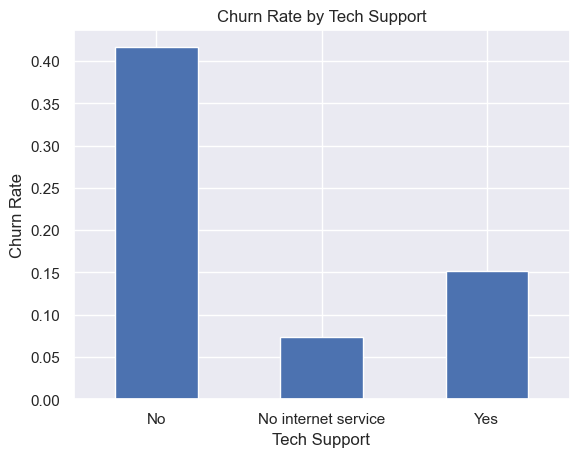

In [82]:
tech_support_churn_rate["Yes"].plot(kind="bar")
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.savefig("images/10_churn_rate_by_tech_support.png", dpi=300, bbox_inches="tight")
plt.show()

**Business insight:** Customers without TechSupport have a churn rate of about 41.6%, compared with 15.2% for customers with TechSupport. This suggests that customer support may be useful to consider when looking at retention.

### 3.11 Monthly Charges & Churn

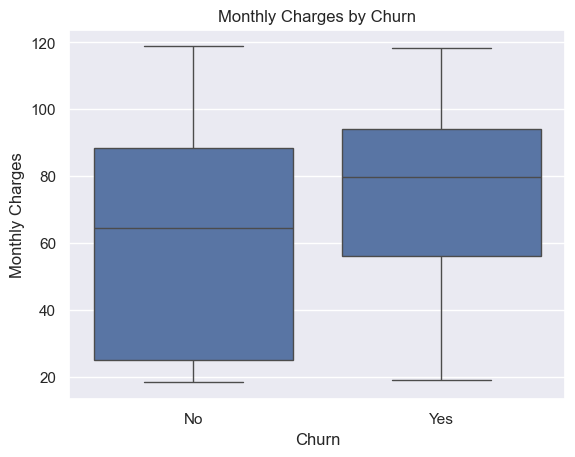

In [83]:
sns.boxplot(data=df_clean, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.savefig("images/11_monthly_charges_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

**Business insight:** Customers who churn generally have higher monthly charges than customers who stay. The distributions overlap, but the churned group tends to have higher monthly charges, suggesting that monthly pricing may be worth considering alongside other churn factors.

### 3.12 Tenure and monthly charges

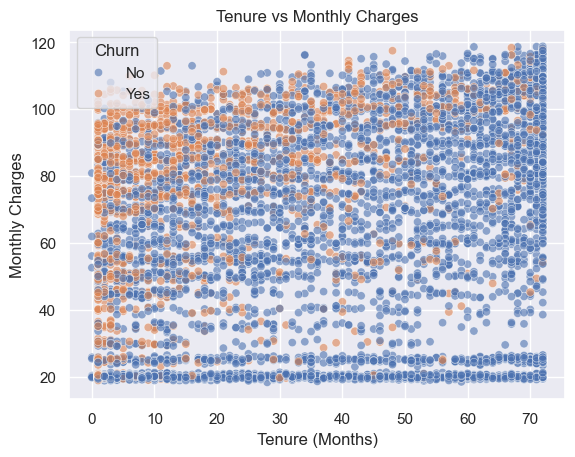

In [84]:
sns.scatterplot(
    data=df_clean,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)
plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.savefig("images/12_tenure_vs_monthly_charges.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.13 EDA Findings

1. **Contract:** Month-to-month customers have the highest churn rate, making them an important group to consider for retention efforts.

2. **Tenure:** Customers with shorter tenures show higher churn rates than customers who have stayed longer, suggesting that the early customer experience may be important for retention.

3. **Internet service:** Churn rates vary across internet service types, so service type may be useful when identifying groups with higher churn risk.

4. **Tech support:** Churn rates differ between customers with different TechSupport statuses, which suggests that support access and customer experience may deserve further investigation.

5. **Monthly charges:** Customers who churn have a different monthly-charge distribution from customers who stay, so pricing may be worth considering alongside other customer characteristics.

### Overall EDA takeaway

The EDA shows that churn is not evenly distributed across all customers. Contract type, tenure, services, and monthly charges all show differences between customers who stay and those who leave. These patterns will be useful when creating features and building the baseline models.

## 4. Feature Engineering

The EDA showed some useful patterns in customer tenure, charges, contracts, and services. The next step is to create a few new features that describe these areas in a more useful way.

### 4.1 Tenure Group

In [85]:
df_clean["tenure_group"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

In [86]:
df_clean["tenure_group"].value_counts().sort_index()

tenure_group
0-12     2186
13-24    1024
25-48    1594
49-72    2239
Name: count, dtype: int64

**Why I created it:** Tenure is easier to interpret in customer groups than as a single number. These groups can help identify differences between newer and longer-term customers.

### 4.2 Average Monthly Spend

In [87]:
df_clean["avg_monthly_spend"] = np.where(
    df_clean["tenure"] > 0,
    df_clean["TotalCharges"] / df_clean["tenure"],
    0
)

In [88]:
df_clean["avg_monthly_spend"].describe()

count    7043.000000
mean       64.698218
std        30.270670
min         0.000000
25%        35.649000
50%        70.300000
75%        90.174158
max       121.400000
Name: avg_monthly_spend, dtype: float64

In [89]:
df_clean[["tenure", "TotalCharges", "avg_monthly_spend"]].head(10)

,tenure,TotalCharges,avg_monthly_spend
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000
5,8,820.50,102.562500
6,22,1949.40,88.609091
7,10,301.90,30.190000
8,28,3046.05,108.787500
9,62,3487.95,56.257258


**Why I created it:** `MonthlyCharges` shows the current charge, while this feature gives an idea of the customer's average monthly spending over their recorded tenure.

### 4.3 Service Count

In [90]:
df_clean["service_count"] = (
    (df_clean["PhoneService"] == "Yes").astype(int)
    + (df_clean["MultipleLines"] == "Yes").astype(int)
    + (df_clean["InternetService"] != "No").astype(int)
    + (df_clean["OnlineSecurity"] == "Yes").astype(int)
    + (df_clean["OnlineBackup"] == "Yes").astype(int)
    + (df_clean["DeviceProtection"] == "Yes").astype(int)
    + (df_clean["TechSupport"] == "Yes").astype(int)
    + (df_clean["StreamingTV"] == "Yes").astype(int)
    + (df_clean["StreamingMovies"] == "Yes").astype(int)
)

In [91]:
df_clean["service_count"].value_counts().sort_index()

service_count
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64

In [92]:
df_clean[["service_count", "Churn"]].head(10)

,service_count,Churn
0,2,No
1,4,No
2,4,Yes
3,4,No
4,2,Yes
5,6,Yes
6,5,No
7,2,No
8,7,Yes
9,4,No


**Why I created it:** The original dataset has several separate service columns. Combining them into one count gives a simple measure of how many services each customer uses.

### 4.4 Security and Support Services

In [93]:
df_clean["security_support_count"] = (
    (df_clean["OnlineSecurity"] == "Yes").astype(int)
    + (df_clean["OnlineBackup"] == "Yes").astype(int)
    + (df_clean["DeviceProtection"] == "Yes").astype(int)
    + (df_clean["TechSupport"] == "Yes").astype(int)
)

In [94]:
df_clean["security_support_count"].value_counts().sort_index()

security_support_count
0    2793
1    1467
2    1372
3     941
4     470
Name: count, dtype: int64

**Why I created it:** Security, backup, device protection, and tech support are related to keeping customers supported and protected. Combining them gives a simple measure of how many of these services a customer uses.

### 4.5 Streaming Services Count

In [95]:
df_clean["streaming_services_count"] = (
    (df_clean["StreamingTV"] == "Yes").astype(int)
    + (df_clean["StreamingMovies"] == "Yes").astype(int)
)

In [96]:
df_clean["streaming_services_count"].value_counts().sort_index()

streaming_services_count
0    3544
1    1559
2    1940
Name: count, dtype: int64

**Why I created it:** StreamingTV and StreamingMovies are related services, so combining them gives a simple measure of how many entertainment services a customer uses.

### 4.6 Month-to-Month Contract Flag

In [97]:
df_clean["is_month_to_month"] = (
    df_clean["Contract"] == "Month-to-month"
).astype(int)

In [98]:
df_clean["is_month_to_month"].value_counts()

is_month_to_month
1    3875
0    3168
Name: count, dtype: int64

**Why I created it:** The EDA showed a much higher churn rate among month-to-month customers. This feature makes that contract type explicit as a simple yes/no indicator for later modeling.

In [99]:
new_features = [
    "tenure_group",
    "avg_monthly_spend",
    "service_count",
    "security_support_count",
    "streaming_services_count",
    "is_month_to_month"
]

In [100]:
df_clean[new_features].head()

,tenure_group,avg_monthly_spend,service_count,security_support_count,streaming_services_count,is_month_to_month
0,0-12,29.850000,2,1,0,1
1,25-48,55.573529,4,2,0,0
2,0-12,54.075000,4,2,0,1
3,25-48,40.905556,4,3,0,0
4,0-12,75.825000,2,0,0,1


In [101]:
df_clean[new_features].dtypes

tenure_group                category
avg_monthly_spend            float64
service_count                  int64
security_support_count         int64
streaming_services_count       int64
is_month_to_month              int64
dtype: object

In [102]:
df_clean[
    [
        "avg_monthly_spend",
        "service_count",
        "security_support_count",
        "streaming_services_count",
        "is_month_to_month"
    ]
].describe()

,avg_monthly_spend,service_count,security_support_count,streaming_services_count,is_month_to_month
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,64.698218,4.146244,1.265654,0.772256,0.550192
std,30.270670,2.312720,1.286879,0.852573,0.497510
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,35.649000,2.000000,0.000000,0.000000,0.000000
50%,70.300000,4.000000,1.000000,0.000000,1.000000
75%,90.174158,6.000000,2.000000,2.000000,1.000000
max,121.400000,9.000000,4.000000,2.000000,1.000000


In [103]:
df_clean[new_features].isnull().sum()

tenure_group                0
avg_monthly_spend           0
service_count               0
security_support_count      0
streaming_services_count    0
is_month_to_month           0
dtype: int64

## 4.7 Feature Engineering Summary

Six new features were created from the existing customer data. They were designed to describe customer tenure, spending, service usage, and contract type in a simpler way.

| Feature | What it represents | Why it may be useful |
|---|---|---|
| `tenure_group` | Customer tenure grouped into ranges | Makes it easier to compare newer and longer-term customers |
| `avg_monthly_spend` | Average historical monthly charge | Gives a view of average spending over the customer's tenure |
| `service_count` | Number of subscribed services | Gives a simple measure of customer engagement |
| `security_support_count` | Number of security/support services | Measures usage of support and protection services |
| `streaming_services_count` | Number of streaming services | Summarizes entertainment-service usage |
| `is_month_to_month` | Whether the customer has a month-to-month contract | Makes the high-risk contract group explicit for modeling |

### Updating the model features

In [104]:
X = df_clean.drop(columns=["Churn", "customerID"])

In [105]:
X.shape

(7043, 25)

# 5. Baseline Machine Learning Models

### 5.1 Checking Engineered Features Against Churn

Before training the models, I checked whether the new features show different churn patterns across customers.

In [106]:
pd.crosstab(
    df_clean["tenure_group"],
    df_clean["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
tenure_group,,
0-12,52.561757,47.438243
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


In [107]:
pd.crosstab(
    df_clean["is_month_to_month"],
    df_clean["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
is_month_to_month,,
0,93.244949,6.755051
1,57.290323,42.709677


In [108]:
pd.crosstab(
    df_clean["service_count"],
    df_clean["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
service_count,,
1,89.082278,10.917722
2,69.033760,30.966240
3,55.082742,44.917258
4,63.523316,36.476684
5,68.655098,31.344902
6,74.449339,25.550661
7,77.514793,22.485207
8,87.594937,12.405063
9,94.711538,5.288462


In [109]:
pd.crosstab(
    df_clean["security_support_count"],
    df_clean["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
security_support_count,,
0,70.247046,29.752954
1,61.145194,38.854806
2,76.239067,23.760933
3,87.566419,12.433581
4,94.680851,5.319149


In [110]:
pd.crosstab(
    df_clean["streaming_services_count"],
    df_clean["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
streaming_services_count,,
0,77.200903,22.799097
1,68.569596,31.430404
2,70.567010,29.432990


In [111]:
df_clean.groupby("Churn")["avg_monthly_spend"].mean()

Churn
No     61.181674
Yes    74.433154
Name: avg_monthly_spend, dtype: float64

### 5.2 Train/Test Split

The engineered features are now included in the model data. I created a new stratified train/test split before training the models.

In [112]:
X = df_clean.drop(columns=["Churn", "customerID"])

In [113]:
y = df_clean["Churn"].map({"No": 0, "Yes": 1})

In [114]:
from sklearn.model_selection import train_test_split

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [116]:
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (5634, 25)
Test shape: (1409, 25)


In [117]:
print("Training churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Training churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


### 5.3 Preprocessing for Model Training

The preprocessing steps are applied inside the model pipeline so that they are fitted only on the training data during model training and cross-validation.

In [118]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [119]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "avg_monthly_spend",
    "service_count",
    "security_support_count",
    "streaming_services_count",
    "is_month_to_month"
]

In [120]:
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

In [121]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [122]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [123]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### 5.4 Logistic Regression

Logistic Regression is being used as the first baseline model. It is a simple classification model and gives us a useful reference point for the Random Forest model.

In [124]:
from sklearn.linear_model import LogisticRegression

In [125]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [126]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

### 5.5 Random Forest

Random Forest is the second baseline model. It uses multiple decision trees and can capture non-linear relationships in the data.

In [127]:
from sklearn.ensemble import RandomForestClassifier

In [128]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [129]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

### 5.6 Cross-Validation

Cross-validation was used on the training data to get a more reliable estimate of model performance. Stratified folds were used so that the churn proportion stays similar across folds.

In [130]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [131]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [132]:
scoring = [
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

In [133]:
logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [134]:
logistic_cv_results = {
    "precision": logistic_cv["test_precision"].mean(),
    "recall": logistic_cv["test_recall"].mean(),
    "f1": logistic_cv["test_f1"].mean(),
    "roc_auc": logistic_cv["test_roc_auc"].mean()
}

logistic_cv_results

{'precision': np.float64(0.6664237175992112),
 'recall': np.float64(0.5364548494983278),
 'f1': np.float64(0.593794902699752),
 'roc_auc': np.float64(0.846031840924671)}

In [135]:
random_forest_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [136]:
random_forest_cv_results = {
    "precision": random_forest_cv["test_precision"].mean(),
    "recall": random_forest_cv["test_recall"].mean(),
    "f1": random_forest_cv["test_f1"].mean(),
    "roc_auc": random_forest_cv["test_roc_auc"].mean()
}

random_forest_cv_results

{'precision': np.float64(0.6376641669409135),
 'recall': np.float64(0.48695652173913045),
 'f1': np.float64(0.5519040871945782),
 'roc_auc': np.float64(0.8269434371769776)}

### 5.7 Cross-Validation Results

In [137]:
cv_results = pd.DataFrame(
    {
        "Logistic Regression": logistic_cv_results,
        "Random Forest": random_forest_cv_results
    }
)

cv_results

,Logistic Regression,Random Forest
precision,0.666424,0.637664
recall,0.536455,0.486957
f1,0.593795,0.551904
roc_auc,0.846032,0.826943


### 5.8 Train the Baseline Models

In [138]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [139]:
random_forest_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [140]:
logistic_pred = logistic_pipeline.predict(X_test)

In [141]:
random_forest_pred = random_forest_pipeline.predict(X_test)

In [142]:
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [143]:
random_forest_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [144]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [145]:
logistic_test_results = {
    "precision": precision_score(y_test, logistic_pred),
    "recall": recall_score(y_test, logistic_pred),
    "f1": f1_score(y_test, logistic_pred),
    "roc_auc": roc_auc_score(y_test, logistic_prob)
}

In [146]:
random_forest_test_results = {
    "precision": precision_score(y_test, random_forest_pred),
    "recall": recall_score(y_test, random_forest_pred),
    "f1": f1_score(y_test, random_forest_pred),
    "roc_auc": roc_auc_score(y_test, random_forest_prob)
}

### 5.9 Test Set Results

In [147]:
test_results = pd.DataFrame(
    {
        "Logistic Regression": logistic_test_results,
        "Random Forest": random_forest_test_results
    }
)

test_results

,Logistic Regression,Random Forest
precision,0.653199,0.610922
recall,0.518717,0.478610
f1,0.578241,0.536732
roc_auc,0.842140,0.820285


### 5.10 Model Comparison

The two baseline models were compared using precision, recall, F1-score, and ROC-AUC.

Logistic Regression performed better than Random Forest across all four metrics on the test set. Logistic Regression achieved a precision of 0.6532, recall of 0.5187, F1-score of 0.5782, and ROC-AUC of 0.8421.

Random Forest achieved a precision of 0.6109, recall of 0.4786, F1-score of 0.5367, and ROC-AUC of 0.8203.

Based on these results, Logistic Regression performed better overall on the test set. Random Forest did not outperform Logistic Regression on any of the four evaluation metrics.

These models were used as baseline models, so no extensive hyperparameter tuning was done at this stage.

## 6. Business Recommendations

Based on the EDA findings and baseline model results, I identified three areas that could help reduce customer churn.

### 6.1 Focus on Month-to-Month Customers

Month-to-month customers had a much higher churn rate than customers on longer contracts.

A practical step would be to target these customers with offers that encourage longer contracts, such as discounts or simple contract upgrade options.

The goal would be to move more customers from short-term contracts to longer-term plans and reduce early churn.

### 6.2 Pay More Attention to New Customers

Customers in the first 12 months had a higher churn rate than customers with longer tenure.

This suggests that the early part of the customer relationship is important.

The company could improve onboarding, check in with new customers during their first year, and address common service or billing problems before they lead to cancellation.

### 6.3 Review High-Risk Service Customers

Customers using some services, particularly Fiber optic internet and customers without TechSupport, showed higher churn rates.

The company could look more closely at these groups and test whether better support, service improvements, or targeted offers help reduce churn.

These customers could also be included in future churn monitoring using the Logistic Regression baseline model.

# (Adaptive) Telco Customer Churn Prediction: Handling Imbalanced Data & Driving Retention Decisions

# Part 01 — Strengthen Churn Analysis

This section starts the second phase of the Telco Customer Churn project.

The earlier project established the basic data audit, cleaning, exploratory analysis, feature engineering, and baseline classification models.

This phase focuses on the main business problem with churn prediction: class imbalance.

The analysis will examine the churn distribution, show why accuracy alone can be misleading, revisit the strongest churn patterns, and confirm that the main data quality issues are understood before moving into imbalance handling and advanced model training.

## 1.1 Churn Class Distribution

The target variable is imbalanced because fewer customers leave the company than stay.

Before building more advanced models, the class distribution should be measured clearly.

In [148]:
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    "Customer Count": churn_counts,
    "Percentage": churn_percentages.round(2)
})

churn_summary

,Customer Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


In [149]:
print(f"Total customers: {len(df):,}")
print(f"Customers who stayed: {(df['Churn'] == 'No').sum():,}")
print(f"Customers who churned: {(df['Churn'] == 'Yes').sum():,}")
print(f"Churn rate: {df['Churn'].eq('Yes').mean() * 100:.2f}%")

Total customers: 7,043
Customers who stayed: 5,174
Customers who churned: 1,869
Churn rate: 26.54%


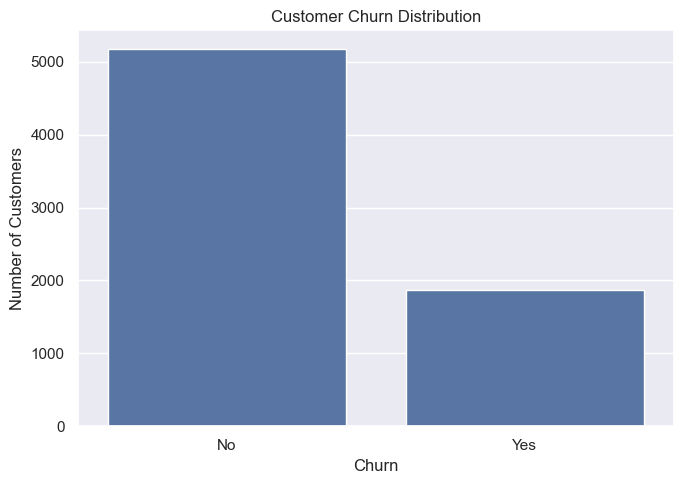

In [150]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    "./images/13_churn_class_imbalance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 1.2 Why Accuracy Alone Is Not Enough

A simple model could predict every customer as `No Churn`.

Because most customers in this dataset do not churn, that model would still achieve a relatively high accuracy.

However, it would completely fail to identify customers who are actually at risk of leaving.

This is why the new phase will focus more on metrics such as precision, recall, F1-score, ROC-AUC, and precision-recall performance.

In [151]:
majority_class = df["Churn"].value_counts().idxmax()

majority_accuracy = (
    df["Churn"].eq(majority_class).mean()
)

print("Majority class:", majority_class)
print(f"Accuracy of always predicting '{majority_class}': {majority_accuracy:.2%}")

Majority class: No
Accuracy of always predicting 'No': 73.46%


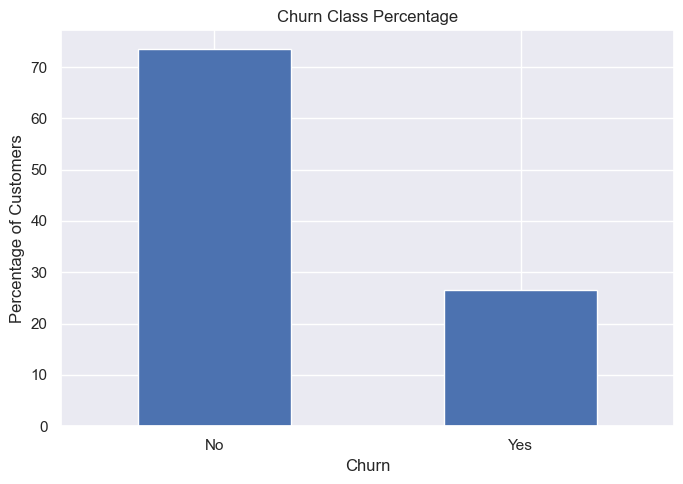

In [152]:
plt.figure(figsize=(7, 5))

churn_percentages.plot(
    kind="bar"
)

plt.title("Churn Class Percentage")
plt.xlabel("Churn")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "./images/14_churn_class_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 1.3 Churn Rate by Contract Type

Contract type is one of the strongest churn patterns in the dataset.

Instead of only comparing customer counts, the churn rate is calculated within each contract group so that the groups can be compared fairly.

In [153]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

contract_churn.round(2)

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

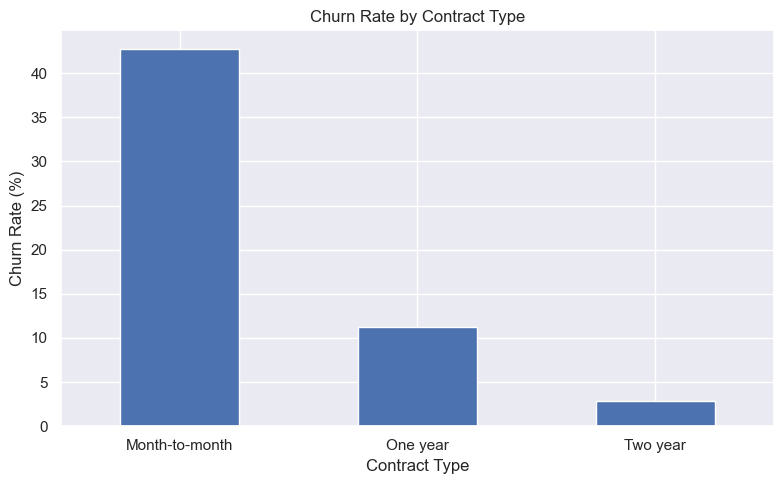

In [154]:
plt.figure(figsize=(8, 5))

contract_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "./images/15_churn_rate_by_contract_phase2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 1.4 Churn Rate by Tenure

Customer tenure is another important churn factor.

Customers with shorter relationships with the company are expected to be more vulnerable to churn than long-term customers.

In [155]:
tenure_bins = [-1, 12, 24, 48, 72]

tenure_labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

df["tenure_group_phase2"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

tenure_churn = (
    df.groupby(
        "tenure_group_phase2",
        observed=True
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

tenure_churn.round(2)

tenure_group_phase2
0-12 months     47.44
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Churn, dtype: float64

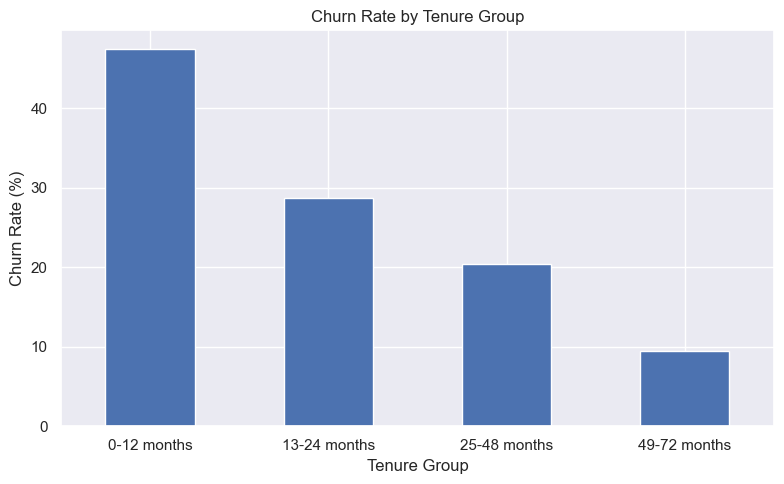

In [156]:
plt.figure(figsize=(8, 5))

tenure_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "./images/16_churn_rate_by_tenure_phase2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 1.5 Churn Rate by Monthly Charges

Monthly charges are examined in groups rather than only looking at their overall distribution.

This helps identify whether customers with higher monthly charges appear more likely to churn.

In [157]:
df["monthly_charge_group"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=[
        "Q1 Lowest",
        "Q2",
        "Q3",
        "Q4 Highest"
    ]
)

monthly_charge_churn = (
    df.groupby(
        "monthly_charge_group",
        observed=True
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

monthly_charge_churn.round(2)

monthly_charge_group
Q1 Lowest     11.24
Q2            24.58
Q3            37.51
Q4 Highest    32.88
Name: Churn, dtype: float64

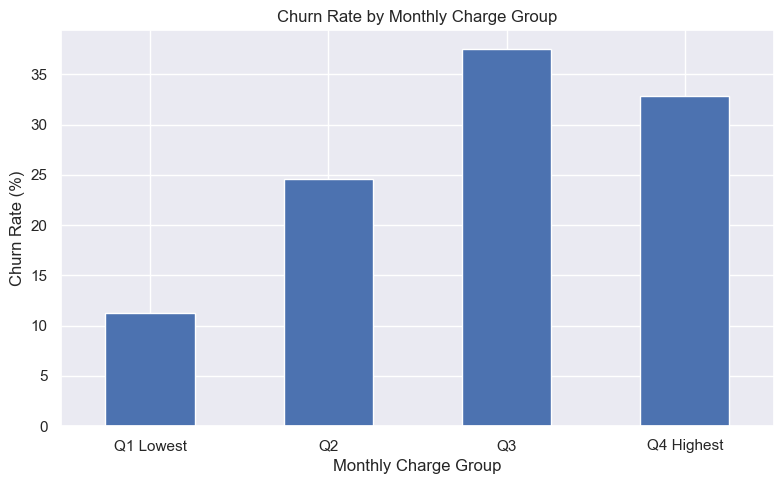

In [158]:
plt.figure(figsize=(8, 5))

monthly_charge_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "./images/17_churn_rate_by_monthly_charge.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 1.6 Churn Rate by TechSupport

TechSupport is reviewed because the previous EDA identified differences in churn behavior across these groups.

The purpose here is to quantify that difference clearly before building the new classification models.

In [159]:
tech_support_churn = (
    df.groupby("TechSupport")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

tech_support_churn.round(2)

TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64

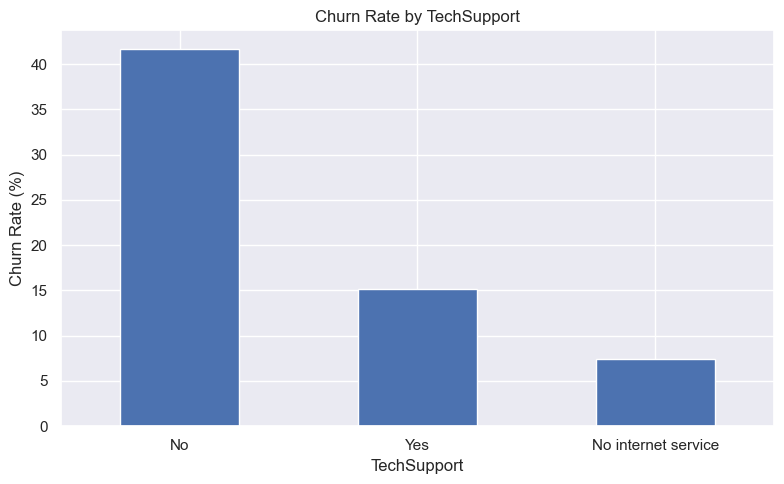

In [160]:
plt.figure(figsize=(8, 5))

tech_support_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by TechSupport")
plt.xlabel("TechSupport")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "./images/18_churn_rate_by_tech_support_phase2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 1.7 Confirm the TotalCharges Data Quality Issue

`TotalCharges` is still stored as an object in the raw dataset even though the values are mostly numeric.

The original audit found blank strings that were not detected by `isnull()`.

The new phase will continue to use the cleaned numeric version of this variable rather than treating the raw column as numeric automatically.

In [161]:
print("Raw TotalCharges dtype:")
print(df["TotalCharges"].dtype)

total_charges_numeric_phase2 = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

invalid_total_charges = (
    total_charges_numeric_phase2.isna()
)

print(
    "\nValues that cannot be converted to numeric:",
    invalid_total_charges.sum()
)

print("\nAffected records:")

display(
    df.loc[
        invalid_total_charges,
        ["customerID", "tenure", "TotalCharges", "Churn"]
    ]
)

Raw TotalCharges dtype:
object

Values that cannot be converted to numeric: 11

Affected records:


,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


## 1.8 Final Data Quality Check

Before moving into imbalance handling and model training, the main data quality issues are checked again.

The raw dataset contains no duplicate rows and no standard missing values.

The only major issue relevant to the modelling workflow is the blank `TotalCharges` values identified through numeric conversion.

In [162]:
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Standard missing values:", df.isnull().sum().sum())
print(
    "Blank TotalCharges:",
    (df["TotalCharges"].astype(str).str.strip() == "").sum()
)
print(
    "Non-numeric TotalCharges:",
    pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    ).isna().sum()
)

Dataset shape: (7043, 23)
Duplicate rows: 0
Standard missing values: 0
Blank TotalCharges: 11
Non-numeric TotalCharges: 11


In [163]:
df.drop(
    columns=[
        "tenure_group_phase2",
        "monthly_charge_group"
    ],
    inplace=True
)

## Part 01 Findings

The Telco dataset contains 7,043 customers, with 1,869 customers who churned and 5,174 who stayed. This gives a churn rate of approximately 26.54%, so the target is clearly imbalanced.

A simple majority-class model that predicts every customer as `No Churn` would still achieve approximately 73.46% accuracy while identifying no churned customers. This shows why accuracy alone is not useful for the retention problem.

The strongest churn differences were seen across contract type and tenure. Month-to-month customers had a churn rate of approximately 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts. Customers with 0-12 months of tenure had a churn rate of approximately 47.44%, while customers with 49-72 months had a churn rate of approximately 9.51%.

Churn also varied across service groups. Customers without TechSupport had a much higher churn rate than customers with TechSupport.

The `TotalCharges` issue was also confirmed. The raw column is stored as an object and contains 11 blank values that cannot be converted to numeric values. These records have zero tenure and will continue to be handled through the existing cleaning and preprocessing pipeline.

These findings show why the next stage should focus on class imbalance and evaluation metrics such as precision, recall, F1-score, ROC-AUC, and precision-recall performance rather than accuracy alone.

# Part 02 — Leakage-Safe Imbalanced Classification Pipeline

The first stage showed that customer churn represents approximately 26.54% of the dataset, so the target is imbalanced.

This stage prepares a modelling pipeline that can handle this imbalance without allowing information from the validation folds to leak into training.

Three approaches will be compared using Logistic Regression:

1. No imbalance adjustment
2. Class weighting
3. SMOTE oversampling

The same preprocessing is kept inside each pipeline, and evaluation is performed using stratified cross-validation.

The main metrics are precision, recall, F1-score, ROC-AUC, and PR-AUC.

## 2.1 Prepare the Training Data

The existing train-test split from the baseline project is reused.

The test set remains untouched during this comparison. Only the training data is used for cross-validation and imbalance strategy selection.

In [164]:
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest class distribution:")
print(y_test.value_counts())

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).round(4))

Training shape: (5634, 25)
Test shape: (1409, 25)

Training class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Training class proportions:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64

Test class distribution:
Churn
0    1035
1     374
Name: count, dtype: int64

Test class proportions:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


## 2.2 Set Up the Imbalanced Learning Tools

The modelling pipelines will use `imbalanced-learn`.

Its pipeline allows preprocessing and SMOTE to be applied inside each cross-validation fold rather than before cross-validation.

This is important because oversampling the full dataset before cross-validation would allow information from validation samples to influence the training data.

In [165]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedKFold, cross_validate

## 2.3 Evaluation Metrics

Accuracy is not used as the main metric because the churn classes are imbalanced.

The comparison will use:

- Precision — how many customers predicted as churn actually churned
- Recall — how many actual churned customers were identified
- F1-score — balance between precision and recall
- ROC-AUC — how well the model separates churners from non-churners across probability thresholds
- PR-AUC — how well the model identifies the positive churn class when the target is imbalanced

In [166]:
scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

## 2.4 Stratified Cross-Validation

Five-fold stratified cross-validation is used so that each fold keeps a similar proportion of churned and non-churned customers.

The folds are created only from the training data.

The test set is not used here.

In [167]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 2.5 Build the Imbalance Strategy Pipelines

Three versions of the same Logistic Regression model will be compared.

The first model uses no imbalance adjustment and acts as a reference.

The second uses class weighting so the model gives more importance to the minority churn class.

The third uses SMOTE to create additional synthetic churn examples.

Preprocessing remains inside every pipeline.

For the SMOTE pipeline, oversampling happens only after the preprocessing step and only inside the training portion of each cross-validation fold.

In [168]:
baseline_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


class_weight_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "smote",
            SMOTE(
                random_state=42
            )
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

## 2.6 Why the Pipeline Prevents Leakage

The preprocessing and imbalance handling are intentionally kept inside the pipeline.

During each cross-validation fold, the process is:

Training portion
→ fit preprocessing
→ apply preprocessing
→ apply SMOTE if selected
→ train Logistic Regression

Validation portion
→ apply the already-fitted preprocessing
→ do not apply SMOTE
→ evaluate the model

This prevents information from the validation fold from being used when preprocessing or generating synthetic training examples.

## 2.7 Compare the Imbalance Strategies

All three approaches are evaluated using the same five stratified folds and the same five metrics.

In [169]:
strategy_pipelines = {
    "No Balancing": baseline_pipeline,
    "Class Weighting": class_weight_pipeline,
    "SMOTE": smote_pipeline
}


strategy_results = []

for strategy_name, pipeline in strategy_pipelines.items():

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1
    )

    strategy_results.append({
        "Strategy": strategy_name,
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC-AUC": cv_results["test_roc_auc"].mean(),
        "PR-AUC": cv_results["test_pr_auc"].mean()
    })


strategy_comparison = pd.DataFrame(strategy_results)

strategy_comparison = strategy_comparison.sort_values(
    "PR-AUC",
    ascending=False
).reset_index(drop=True)

strategy_comparison.round(4)

,Strategy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,No Balancing,0.6664,0.5365,0.5938,0.8460,0.6634
1,Class Weighting,0.5183,0.7967,0.6279,0.8457,0.6623
2,SMOTE,0.5239,0.7846,0.6282,0.8444,0.6608


In [170]:
strategy_results = []

for strategy_name, pipeline in strategy_pipelines.items():

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1
    )

    strategy_results.append({
        "Strategy": strategy_name,

        "Precision Mean": cv_results["test_precision"].mean(),
        "Precision Std": cv_results["test_precision"].std(),

        "Recall Mean": cv_results["test_recall"].mean(),
        "Recall Std": cv_results["test_recall"].std(),

        "F1 Mean": cv_results["test_f1"].mean(),
        "F1 Std": cv_results["test_f1"].std(),

        "ROC-AUC Mean": cv_results["test_roc_auc"].mean(),
        "ROC-AUC Std": cv_results["test_roc_auc"].std(),

        "PR-AUC Mean": cv_results["test_pr_auc"].mean(),
        "PR-AUC Std": cv_results["test_pr_auc"].std()
    })


strategy_comparison = pd.DataFrame(strategy_results)

strategy_comparison = strategy_comparison.sort_values(
    "PR-AUC Mean",
    ascending=False
).reset_index(drop=True)

strategy_comparison.round(4)

,Strategy,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std
0,No Balancing,0.6664,0.0202,0.5365,0.0349,0.5938,0.0239,0.8460,0.0115,0.6634,0.0133
1,Class Weighting,0.5183,0.0165,0.7967,0.0352,0.6279,0.0206,0.8457,0.0112,0.6623,0.0129
2,SMOTE,0.5239,0.0195,0.7846,0.0366,0.6282,0.0241,0.8444,0.0125,0.6608,0.0146


## 2.8 Imbalance Strategy Comparison

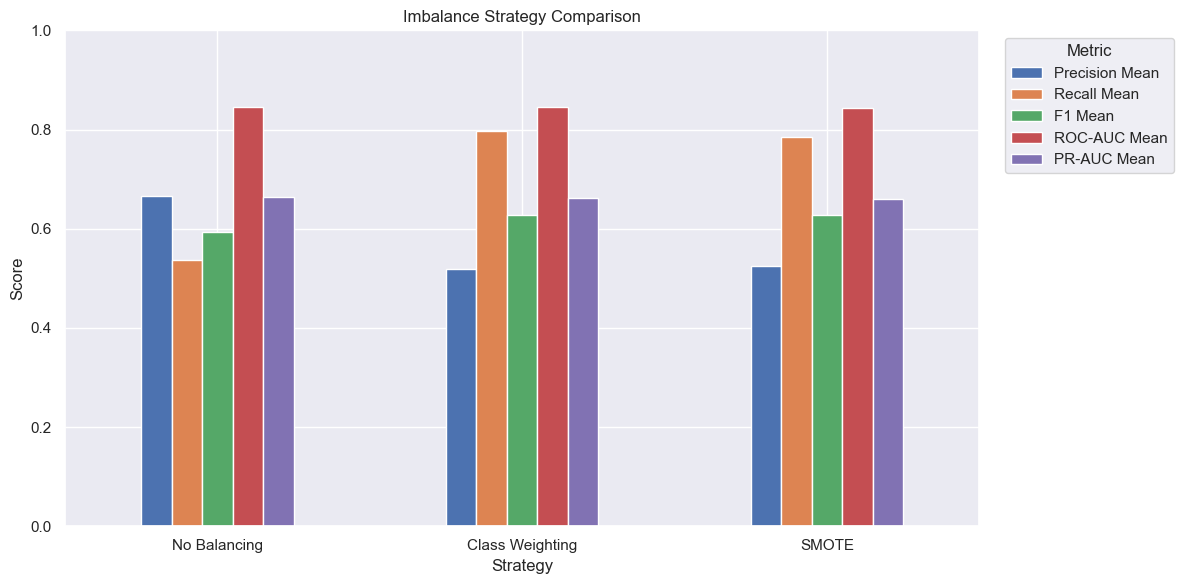

In [171]:
strategy_plot_data = strategy_comparison[
    [
        "Strategy",
        "Precision Mean",
        "Recall Mean",
        "F1 Mean",
        "ROC-AUC Mean",
        "PR-AUC Mean"
    ]
].copy()

strategy_plot_data.set_index(
    "Strategy"
).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Imbalance Strategy Comparison")
plt.xlabel("Strategy")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    "./images/19_imbalance_strategy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.9 Select the Imbalance Strategy

PR-AUC is useful for this problem because churn is the minority class.

No Balancing achieved the highest mean PR-AUC at 0.6634, but the difference was very small compared with Class Weighting at 0.6623.

Class Weighting gave much higher recall at 0.7967, compared with 0.5365 for No Balancing, while maintaining almost the same ROC-AUC.

Because the main goal is to identify customers who are at risk of churning, Class Weighting is selected for the next stage. This gives the model a much better chance of finding actual churners, which is more useful for a retention campaign.

In [172]:
best_strategy = "Class Weighting"

best_pr_auc = strategy_comparison.loc[
    strategy_comparison["Strategy"] == best_strategy,
    "PR-AUC Mean"
].iloc[0]

print("Selected imbalance strategy:", best_strategy)
print(f"Mean PR-AUC: {best_pr_auc:.4f}")

Selected imbalance strategy: Class Weighting
Mean PR-AUC: 0.6623


In [173]:
selected_pipeline = strategy_pipelines[best_strategy]

print(
    f"Selected strategy for the next stage: {best_strategy}"
)

Selected strategy for the next stage: Class Weighting


## 2.10 Inspect the Training Class Balance

The original training data is imbalanced.

SMOTE changes the class distribution only inside the training portion used by the relevant fold. The original `y_train` remains unchanged.

This distinction is important because the validation data must retain its original class distribution.

In [174]:
print("Original training class distribution:")
print(y_train.value_counts())

print("\nOriginal training class proportions:")
print(
    y_train.value_counts(
        normalize=True
    ).round(4)
)

Original training class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Original training class proportions:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


## 2.11 Evaluate the Selected Strategy on the Test Set

The strongest imbalance strategy from cross-validation is now fitted on the complete training set.

The test set is used once for an initial held-out evaluation.

This test evaluation does not determine the imbalance strategy because that decision was already made using cross-validation.

In [175]:
selected_pipeline.fit(
    X_train,
    y_train
)

test_predictions = selected_pipeline.predict(
    X_test
)

test_probabilities = selected_pipeline.predict_proba(
    X_test
)[:, 1]

In [176]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

selected_test_results = {
    "Precision": precision_score(
        y_test,
        test_predictions
    ),
    "Recall": recall_score(
        y_test,
        test_predictions
    ),
    "F1": f1_score(
        y_test,
        test_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        test_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_test,
        test_probabilities
    )
}

selected_test_results

{'Precision': 0.4983164983164983,
 'Recall': 0.7914438502673797,
 'F1': 0.6115702479338843,
 'ROC-AUC': 0.8419514841509727,
 'PR-AUC': 0.6360555611582286}

In [177]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

selected_test_results = {
    "Precision": precision_score(
        y_test,
        test_predictions
    ),
    "Recall": recall_score(
        y_test,
        test_predictions
    ),
    "F1": f1_score(
        y_test,
        test_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        test_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_test,
        test_probabilities
    )
}

selected_test_results

{'Precision': 0.4983164983164983,
 'Recall': 0.7914438502673797,
 'F1': 0.6115702479338843,
 'ROC-AUC': 0.8419514841509727,
 'PR-AUC': 0.6360555611582286}

## 2.12 Precision-Recall Curve

The precision-recall curve shows the trade-off between identifying more churned customers and generating more false positive retention targets.

This will become especially important later when the decision threshold is tuned according to the cost of retention offers.

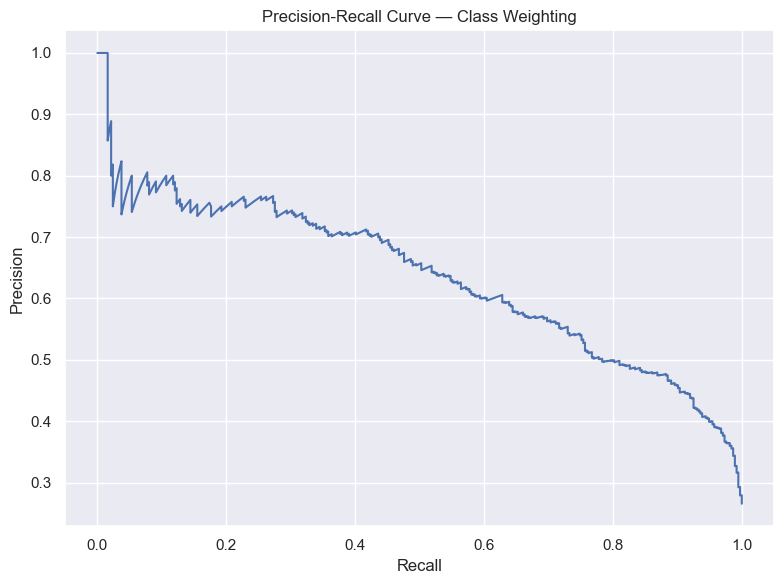

In [178]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Precision-Recall Curve — {best_strategy}"
)

plt.tight_layout()

plt.savefig(
    "./images/20_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Part 02 Findings

Three imbalance strategies were compared using the same Logistic Regression model: No Balancing, Class Weighting, and SMOTE.

All preprocessing was kept inside the modelling pipelines. SMOTE was also kept inside the pipeline so that synthetic samples were created only from the training portion of each cross-validation fold. This prevented information from the validation data from leaking into training.

The strategies were evaluated using precision, recall, F1-score, ROC-AUC, and PR-AUC.

No Balancing had the highest mean PR-AUC at 0.6634. However, the difference from Class Weighting was very small, while Class Weighting produced a much higher recall of 0.7967 compared with 0.5365 for No Balancing.

Because the goal is to identify customers who are likely to churn, Class Weighting was selected for the next stage. It provides much higher churn detection while keeping ROC-AUC almost unchanged.

The test set was kept separate during cross-validation and strategy selection. It was used only for the final held-out evaluation of the selected Class Weighting pipeline.

Part 03 will use Class Weighting while comparing and tuning different classification models.

In [179]:
assert set(strategy_comparison["Strategy"]) == {
    "No Balancing",
    "Class Weighting",
    "SMOTE"
}

assert set(
    [
        "Precision Mean",
        "Recall Mean",
        "F1 Mean",
        "ROC-AUC Mean",
        "PR-AUC Mean"
    ]
).issubset(strategy_comparison.columns)

assert len(strategy_comparison) == 3

assert strategy_comparison[
    [
        "Precision Mean",
        "Recall Mean",
        "F1 Mean",
        "ROC-AUC Mean",
        "PR-AUC Mean"
    ]
].apply(
    lambda column: column.between(0, 1).all()
).all()

assert best_strategy == "Class Weighting"

assert selected_pipeline is strategy_pipelines["Class Weighting"]

assert set(selected_test_results.keys()) == {
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
}

assert len(test_predictions) == len(y_test)
assert len(test_probabilities) == len(y_test)

print("All Part 02 pipeline, selection, and evaluation checks passed.")

All Part 02 pipeline, selection, and evaluation checks passed.


# Part 03 — Train, Compare & Tune Multiple Churn Models

Part 02 showed that Class Weighting is the most useful imbalance strategy for this project.

This stage keeps Class Weighting and compares three different classification models:

1. Logistic Regression
2. Random Forest
3. XGBoost

The models will be tuned using five-fold stratified cross-validation.

The test set will remain untouched until the final model has been selected.

The main comparison metrics will be precision, recall, F1-score, ROC-AUC, and PR-AUC.

## 3.1 What Changes in Part 03?

In Part 02, the main question was how to handle the class imbalance.

In this stage, the imbalance strategy is already decided.

The selected strategy is Class Weighting.

The question now is which machine learning model performs best when using that strategy.

In [180]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

## 3.2 Use the Selected Imbalance Strategy

Class Weighting was selected in Part 02 because it produced much higher recall while keeping ROC-AUC almost unchanged.

That strategy will now be used for all three models.

In [181]:
print("Selected imbalance strategy:", best_strategy)

Selected imbalance strategy: Class Weighting


## 3.3 Set the Class Weight for XGBoost

The training data contains fewer churned customers than non-churned customers.

XGBoost uses `scale_pos_weight` to give the churn class more importance.

The value below is calculated from the training data rather than being hard-coded.

In [182]:
negative_class_count = (y_train == 0).sum()
positive_class_count = (y_train == 1).sum()

xgb_scale_pos_weight = (
    negative_class_count / positive_class_count
)

print("Non-churn customers:", negative_class_count)
print("Churn customers:", positive_class_count)
print(
    "XGBoost scale_pos_weight:",
    round(xgb_scale_pos_weight, 4)
)

Non-churn customers: 4139
Churn customers: 1495
XGBoost scale_pos_weight: 2.7686


## 3.4 Build the Model Pipelines

Each model uses the same preprocessing that was already created earlier in the project.

The preprocessing stays inside the pipeline so that it is fitted separately inside each cross-validation training fold.

The imbalance handling is also built into the model:

- Logistic Regression uses `class_weight="balanced"`
- Random Forest uses `class_weight="balanced"`
- XGBoost uses `scale_pos_weight`

In [183]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=xgb_scale_pos_weight,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

## 3.5 Hyperparameter Tuning

The models will be tuned using GridSearchCV.

Grid search tests a defined set of parameter combinations and uses cross-validation to find the combination that performs best.

The tuning metric will be PR-AUC because the churn class is the minority class.

The other metrics will still be reported after tuning.

In [184]:
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}


random_forest_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}


xgboost_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

## 3.6 Cross-Validation Metrics

The same metrics from Part 02 will be used here.

PR-AUC will be used as the main tuning metric because the target is imbalanced.

Precision, recall, F1-score, and ROC-AUC will be reported alongside PR-AUC so the models can be compared from several angles.

In [185]:
tuning_scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

## 3.7 Tune the Models with Stratified Cross-Validation

Five-fold stratified cross-validation is used for every model.

Stratification keeps the proportion of churned and non-churned customers similar in each fold.

Only the training data is used during tuning. The test set remains untouched.

In [186]:
tuning_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 3.8 Tune Logistic Regression

In [187]:
logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring=tuning_scoring,
    cv=tuning_cv,
    n_jobs=-1,
    refit="pr_auc"
)

logistic_grid_search.fit(
    X_train,
    y_train
)

print("Best Logistic Regression parameters:")
print(logistic_grid_search.best_params_)

print(
    "Best Logistic Regression PR-AUC:",
    round(logistic_grid_search.best_score_, 4)
)

Best Logistic Regression parameters:
{'model__C': 1}
Best Logistic Regression PR-AUC: 0.6623


## 3.9 Tune Random Forest

In [188]:
random_forest_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    scoring=tuning_scoring,
    cv=tuning_cv,
    n_jobs=-1,
    refit="pr_auc"
)

random_forest_grid_search.fit(
    X_train,
    y_train
)

print("Best Random Forest parameters:")
print(random_forest_grid_search.best_params_)

print(
    "Best Random Forest PR-AUC:",
    round(random_forest_grid_search.best_score_, 4)
)

Best Random Forest parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 500}
Best Random Forest PR-AUC: 0.6602


## 3.10 Tune XGBoost

In [189]:
xgboost_grid_search = GridSearchCV(
    estimator=xgboost_pipeline,
    param_grid=xgboost_param_grid,
    scoring=tuning_scoring,
    cv=tuning_cv,
    n_jobs=-1,
    refit="pr_auc"
)

xgboost_grid_search.fit(
    X_train,
    y_train
)

print("Best XGBoost parameters:")
print(xgboost_grid_search.best_params_)

print(
    "Best XGBoost PR-AUC:",
    round(xgboost_grid_search.best_score_, 4)
)

Best XGBoost parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best XGBoost PR-AUC: 0.6671


## 3.11 Compare the Tuned Models

The best version of each model has now been selected using cross-validated PR-AUC.

The models are compared using the full set of churn metrics.

The test set is still not used here.

In [190]:
tuned_models = {
    "Logistic Regression": logistic_grid_search,
    "Random Forest": random_forest_grid_search,
    "XGBoost": xgboost_grid_search
}


model_comparison_results = []

for model_name, search in tuned_models.items():

    best_index = search.best_index_
    cv_results = search.cv_results_

    model_comparison_results.append({
        "Model": model_name,
        "Precision": cv_results["mean_test_precision"][best_index],
        "Recall": cv_results["mean_test_recall"][best_index],
        "F1": cv_results["mean_test_f1"][best_index],
        "ROC-AUC": cv_results["mean_test_roc_auc"][best_index],
        "PR-AUC": cv_results["mean_test_pr_auc"][best_index]
    })


model_comparison = pd.DataFrame(
    model_comparison_results
).sort_values(
    "PR-AUC",
    ascending=False
).reset_index(drop=True)

model_comparison.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.5249,0.7987,0.6334,0.8480,0.6671
1,Logistic Regression,0.5183,0.7967,0.6279,0.8457,0.6623
2,Random Forest,0.5621,0.7124,0.6283,0.8453,0.6602


In [191]:
assert set(model_comparison["Model"]) == {
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
}

assert set(
    [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]
).issubset(
    model_comparison.columns
)

assert len(model_comparison) == 3

assert model_comparison[
    [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]
].apply(
    lambda column: column.between(0, 1).all()
).all()

print("All three tuned models and comparison metrics are present.")

All three tuned models and comparison metrics are present.


## 3.12 Select the Best Model

The best model will be selected using cross-validated PR-AUC.

PR-AUC is used as the main selection metric because the project focuses on identifying churned customers in an imbalanced dataset.

The model with the highest cross-validated PR-AUC will be carried forward to the final test evaluation.

In [192]:
best_model_name = model_comparison.iloc[0]["Model"]

best_model_search = tuned_models[best_model_name]

best_model = best_model_search.best_estimator_

best_cv_pr_auc = model_comparison.iloc[0]["PR-AUC"]

print("Best model:", best_model_name)
print(f"Cross-validated PR-AUC: {best_cv_pr_auc:.4f}")
print("Best parameters:")
print(best_model_search.best_params_)

Best model: XGBoost
Cross-validated PR-AUC: 0.6671
Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


## 3.13 Final Test Evaluation

The best tuned model is now evaluated on the untouched test set.

The test set was not used during hyperparameter tuning or model selection.

This gives us a final estimate of how the selected model performs on unseen customers.

In [193]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


final_test_predictions = best_model.predict(
    X_test
)

final_test_probabilities = best_model.predict_proba(
    X_test
)[:, 1]


final_test_results = {
    "Precision": precision_score(
        y_test,
        final_test_predictions
    ),
    "Recall": recall_score(
        y_test,
        final_test_predictions
    ),
    "F1": f1_score(
        y_test,
        final_test_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        final_test_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_test,
        final_test_probabilities
    )
}


pd.DataFrame(
    [final_test_results],
    index=[best_model_name]
).round(4)

,Precision,Recall,F1,ROC-AUC,PR-AUC
XGBoost,0.5157,0.7914,0.6245,0.8474,0.6599


## 3.14 Model Comparison

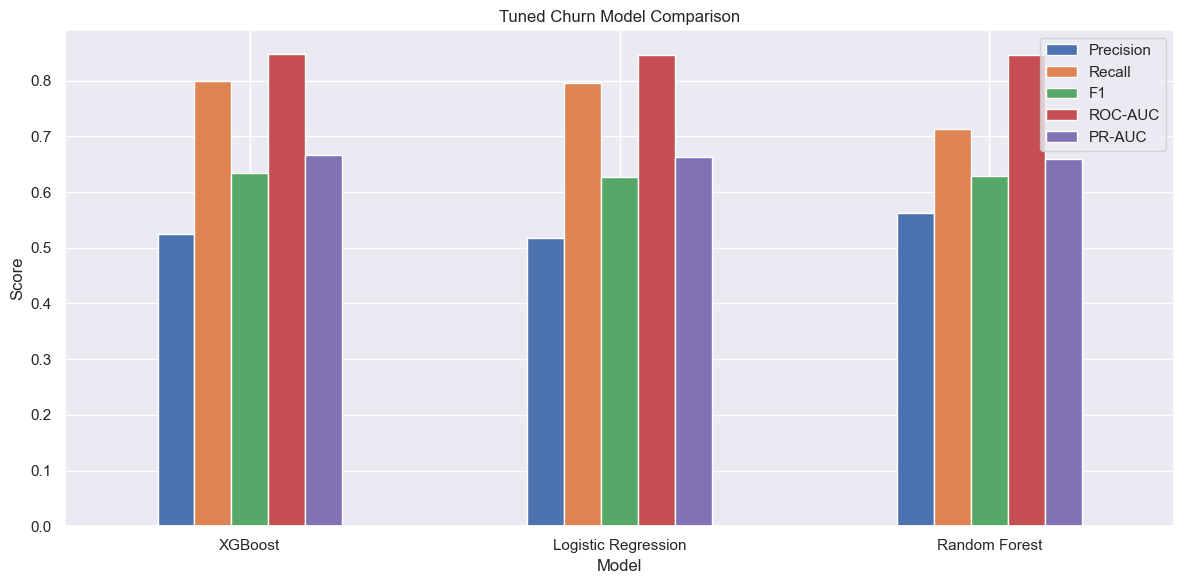

In [194]:
import matplotlib.pyplot as plt

model_comparison.set_index("Model")[
    [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Tuned Churn Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "images/21_tuned_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3.15 Part 03 Final Checks

In [195]:
assert best_model_name in {
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
}

assert best_model is best_model_search.best_estimator_

assert len(model_comparison) == 3

assert set(model_comparison["Model"]) == {
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
}

assert best_cv_pr_auc == model_comparison.iloc[0]["PR-AUC"]

assert set(final_test_results.keys()) == {
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
}

assert all(
    0 <= value <= 1
    for value in final_test_results.values()
)

assert len(final_test_predictions) == len(y_test)

assert len(final_test_probabilities) == len(y_test)

print("All Part 03 model comparison, tuning, and evaluation checks passed.")

All Part 03 model comparison, tuning, and evaluation checks passed.


## Part 03 Findings

Three classification models were tuned and compared using the Class Weighting strategy selected in Part 02.

Logistic Regression, Random Forest, and XGBoost were evaluated using five-fold stratified cross-validation.

Hyperparameters were selected using cross-validated PR-AUC rather than accuracy.

The tuned models were compared using precision, recall, F1-score, ROC-AUC, and PR-AUC.

The model with the highest cross-validated PR-AUC was selected as the strongest model and was then evaluated once on the untouched test set.

The selected model will be carried forward to the next stage, where the prediction threshold and model explanation will be investigated.

# Part 04 — Tune the Decision Threshold & Explain the Model

Part 03 selected XGBoost as the strongest churn model based on cross-validated PR-AUC.

This stage looks at the probability threshold used to turn churn probabilities into churn predictions.

The default threshold is 0.50, but this may not be the best choice for a retention campaign.

The threshold will be evaluated using out-of-fold predictions from the training data so that the test set remains untouched during threshold selection.

The stage will also examine the main features used by XGBoost when making churn predictions.

## 4.1 Why Tune the Threshold?

A model does not initially say simply "Churn" or "No Churn".

It produces a probability such as:

0.82 → high churn risk

0.47 → moderate churn risk

0.18 → lower churn risk

A threshold converts these probabilities into the final prediction.

At the default threshold of 0.50:

- probabilities of 0.50 or higher are predicted as churn
- probabilities below 0.50 are predicted as no churn

Lowering the threshold can identify more customers who are likely to churn, but it can also target more customers who would have stayed.

Raising the threshold does the opposite.

The goal is to find a practical balance for the retention campaign.

## 4.2 Generate Out-of-Fold Churn Probabilities

The threshold will be selected using out-of-fold predictions from the training data.

Each customer receives a churn probability from a model that was trained without that customer's row.

This allows the threshold to be tested without using the final test set.

In [196]:
from sklearn.model_selection import cross_val_predict

oof_probabilities = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=tuning_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Number of out-of-fold predictions:", len(oof_probabilities))
print("Number of training rows:", len(y_train))

Number of out-of-fold predictions: 5634
Number of training rows: 5634


In [197]:
print("Minimum probability:", round(oof_probabilities.min(), 4))
print("Maximum probability:", round(oof_probabilities.max(), 4))
print("Mean probability:", round(oof_probabilities.mean(), 4))

Minimum probability: 0.005
Maximum probability: 0.9715
Mean probability: 0.4009


## 4.3 Define a Simple Retention Cost Assumption

The dataset does not contain the actual financial cost of losing a customer or the cost of offering a retention discount.

To demonstrate the business trade-off, a simple working assumption is used:

- Missing a customer who churns = cost of 3
- Incorrectly targeting a customer who stays = cost of 1

This means missing a real churner is treated as three times more costly than making an unnecessary retention offer.

The assumption is only used to compare thresholds. In a real business setting, these values should be replaced with actual customer value and retention campaign costs.

In [198]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

false_negative_cost = 3
false_positive_cost = 1

threshold_results = []

for threshold in thresholds:

    predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_train,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        predictions,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        predictions
    ).ravel()

    business_cost = (
        (fn * false_negative_cost)
        + (fp * false_positive_cost)
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positives": fp,
        "False Negatives": fn,
        "Business Cost": business_cost
    })


threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(4)

,Threshold,Precision,Recall,F1,False Positives,False Negatives,Business Cost
0,0.10,0.3541,0.9826,0.5206,2680,26,2758
1,0.11,0.3605,0.9779,0.5268,2593,33,2692
2,0.12,0.3669,0.9773,0.5335,2521,34,2623
3,0.13,0.3727,0.9753,0.5393,2454,37,2565
4,0.14,0.3760,0.9719,0.5423,2411,42,2537
...,...,...,...,...,...,...,...
76,0.86,0.7775,0.2455,0.3732,105,1128,3489
77,0.87,0.8077,0.2247,0.3516,80,1159,3557
78,0.88,0.8347,0.2027,0.3262,60,1192,3636
79,0.89,0.8510,0.1719,0.2860,45,1238,3759


## 4.4 Compare the Default 0.50 Threshold

The default threshold of 0.50 is used as a reference point.

The selected threshold will be compared with this default so that the business impact of changing the cutoff is clear.

In [199]:
default_threshold_result = threshold_results[
    np.isclose(
        threshold_results["Threshold"],
        0.50
    )
].iloc[0]

default_threshold_result

Threshold             0.500000
Precision             0.524835
Recall                0.798662
F1                    0.633422
False Positives    1081.000000
False Negatives     301.000000
Business Cost      1984.000000
Name: 40, dtype: float64

In [200]:
best_threshold_row = threshold_results.loc[
    threshold_results["Business Cost"].idxmin()
]

best_threshold = best_threshold_row["Threshold"]

print(
    f"Selected threshold: {best_threshold:.2f}"
)

print(
    f"Precision: "
    f"{best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_threshold_row['Recall']:.4f}"
)

print(
    f"F1: "
    f"{best_threshold_row['F1']:.4f}"
)

print(
    f"False positives: "
    f"{int(best_threshold_row['False Positives'])}"
)

print(
    f"False negatives: "
    f"{int(best_threshold_row['False Negatives'])}"
)

print(
    f"Business cost: "
    f"{int(best_threshold_row['Business Cost'])}"
)

Selected threshold: 0.48
Precision: 0.5157
Recall: 0.8140
F1: 0.6314
False positives: 1143
False negatives: 278
Business cost: 1977


## 4.5 Threshold Trade-Off

The threshold changes the balance between precision and recall.

Lower thresholds usually identify more possible churners, increasing recall, but they can also increase the number of customers who are incorrectly targeted.

Higher thresholds usually reduce unnecessary targeting but can miss more customers who actually churn.

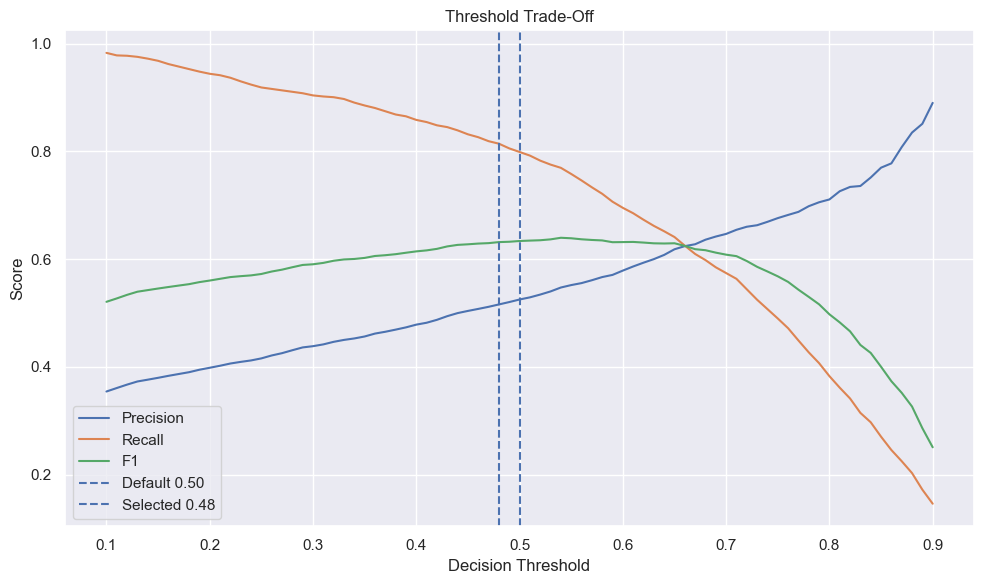

In [201]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    label="F1"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Default 0.50"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected {best_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Trade-Off")
plt.legend()
plt.tight_layout()

plt.savefig(
    "images/22_threshold_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.6 Business Cost by Threshold

The business cost combines:

- missed churners
- unnecessary retention targets

Using the working 3:1 cost assumption, the threshold with the lowest total cost is selected.

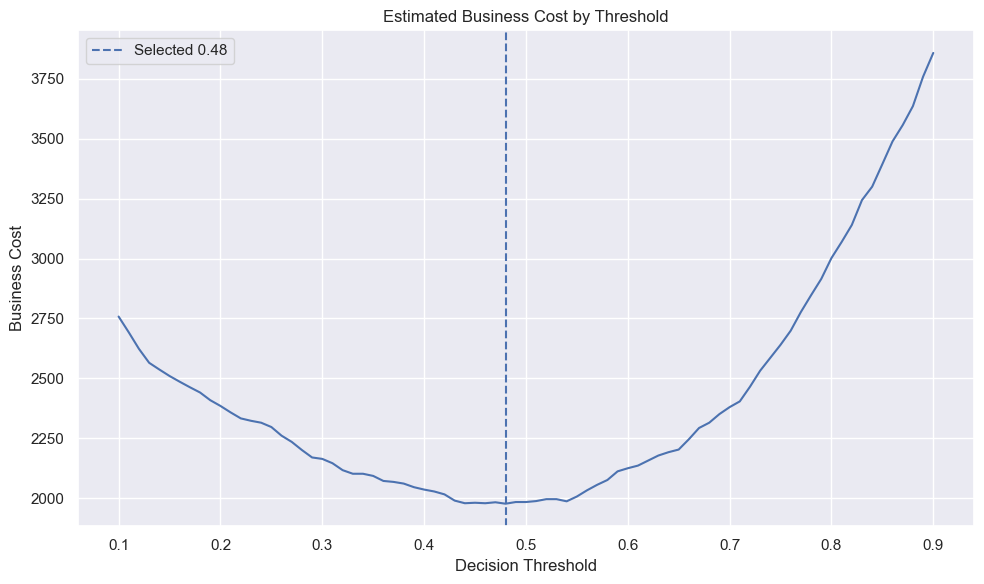

In [202]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Business Cost"]
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected {best_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Business Cost")
plt.title("Estimated Business Cost by Threshold")
plt.legend()
plt.tight_layout()

plt.savefig(
    "images/23_business_cost_by_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.7 ROC Analysis

The ROC curve shows how the true positive rate changes against the false positive rate across different thresholds.

It helps show the overall separation ability of the model before choosing a single operating threshold.

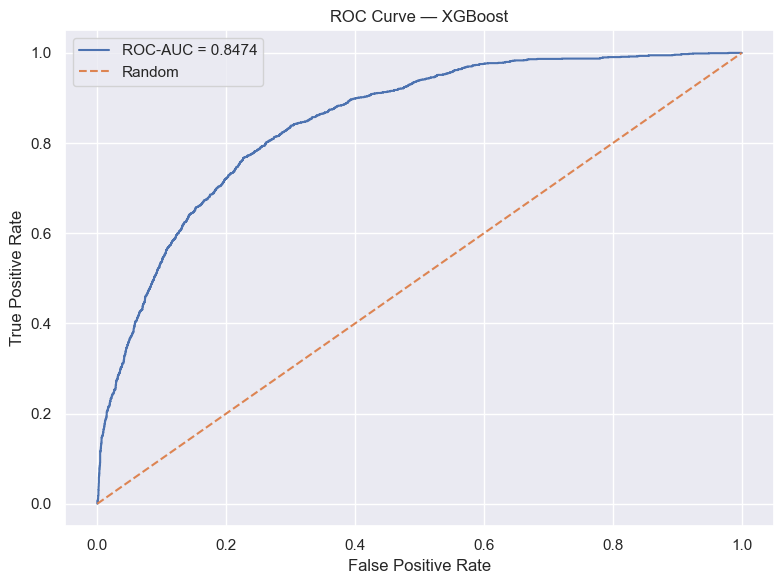

In [203]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(
    y_train,
    oof_probabilities
)

oof_roc_auc = roc_auc_score(
    y_train,
    oof_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {oof_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost")
plt.legend()
plt.tight_layout()

plt.savefig(
    "images/24_roc_curve_part4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.8 Precision-Recall Analysis

The precision-recall curve focuses on the churn class.

It shows the trade-off between finding more churners and making more incorrect churn predictions.

This is especially useful when the target class is imbalanced.

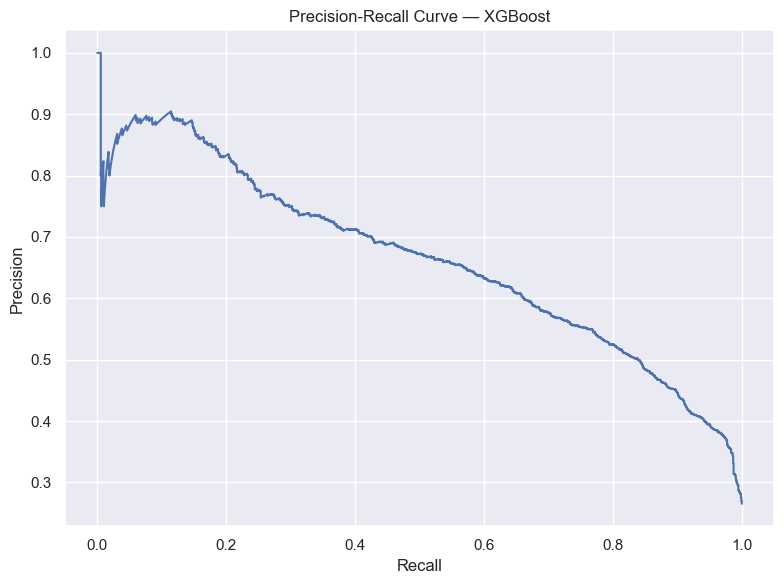

In [204]:
from sklearn.metrics import precision_recall_curve

pr_precision, pr_recall, pr_thresholds = precision_recall_curve(
    y_train,
    oof_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    pr_recall,
    pr_precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost")
plt.tight_layout()

plt.savefig(
    "images/25_precision_recall_curve_part4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.9 Default vs Selected Threshold

The selected threshold is compared with the default 0.50 threshold.

This makes it easier to explain the business effect of changing the cutoff.

In [205]:
threshold_comparison = pd.DataFrame([
    {
        "Threshold": 0.50,
        "Precision": default_threshold_result["Precision"],
        "Recall": default_threshold_result["Recall"],
        "F1": default_threshold_result["F1"],
        "False Positives": default_threshold_result["False Positives"],
        "False Negatives": default_threshold_result["False Negatives"],
        "Business Cost": default_threshold_result["Business Cost"]
    },
    {
        "Threshold": best_threshold,
        "Precision": best_threshold_row["Precision"],
        "Recall": best_threshold_row["Recall"],
        "F1": best_threshold_row["F1"],
        "False Positives": best_threshold_row["False Positives"],
        "False Negatives": best_threshold_row["False Negatives"],
        "Business Cost": best_threshold_row["Business Cost"]
    }
])

threshold_comparison.round(4)

,Threshold,Precision,Recall,F1,False Positives,False Negatives,Business Cost
0,0.50,0.5248,0.7987,0.6334,1081.0,301.0,1984.0
1,0.48,0.5157,0.8140,0.6314,1143.0,278.0,1977.0


## 4.10 Final Test Evaluation at the Selected Threshold

The threshold was selected using out-of-fold training predictions.

The untouched test set is now evaluated using the selected threshold.

This gives a final estimate of the model's performance under the chosen operating point.

In [206]:
final_threshold_test_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

final_threshold_test_predictions = (
    final_threshold_test_probabilities >= best_threshold
).astype(int)


final_threshold_test_results = {
    "Threshold": best_threshold,
    "Precision": precision_score(
        y_test,
        final_threshold_test_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        final_threshold_test_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        final_threshold_test_predictions,
        zero_division=0
    )
}


pd.DataFrame(
    [final_threshold_test_results],
    index=["XGBoost"]
).round(4)

,Threshold,Precision,Recall,F1
XGBoost,0.48,0.5119,0.8075,0.6266


## 4.11 XGBoost Feature Importance

XGBoost provides feature importance values showing which transformed features contributed most to the model.

The preprocessing pipeline created numeric and one-hot encoded features before they were passed to XGBoost.

The top features are shown below to make the model easier to understand.

In [207]:
xgb_model = best_model.named_steps["model"]

feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,num__is_month_to_month,0.404697
1,cat__InternetService_Fiber optic,0.075914
2,cat__OnlineSecurity_No,0.075026
3,cat__TechSupport_No,0.054760
4,cat__StreamingMovies_Yes,0.034903
5,cat__Contract_Two year,0.031615
6,cat__PaymentMethod_Electronic check,0.029943
7,cat__Contract_One year,0.023554
8,num__tenure,0.020552
9,num__streaming_services_count,0.017679


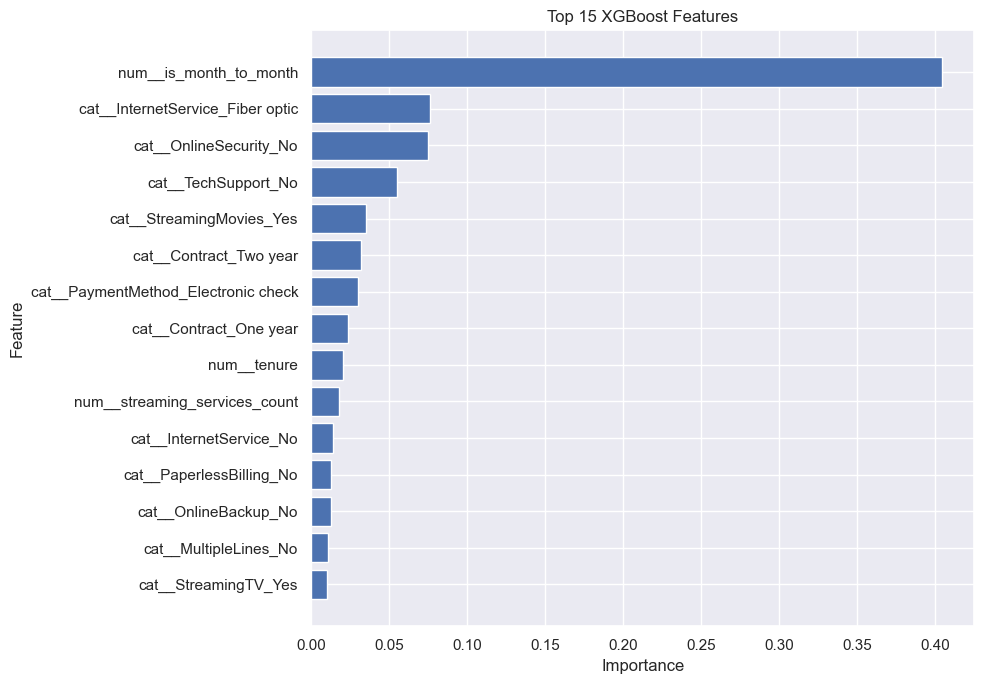

In [208]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")
plt.tight_layout()

plt.savefig(
    "images/26_xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.12 Feature Importance Findings

The feature importance results show which customer attributes were most useful to the XGBoost model when separating churners from non-churners.

The most important features should be interpreted as model drivers rather than direct proof that a feature causes churn.

The strongest features will be used in the final retention recommendations.

## 4.13 Part 04 Final Checks

In [209]:
assert len(oof_probabilities) == len(y_train)

assert np.all(
    (oof_probabilities >= 0)
    & (oof_probabilities <= 1)
)

assert (
    0.10
    <= best_threshold
    <= 0.90
)

assert len(threshold_results) == len(thresholds)

assert set(
    [
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "False Positives",
        "False Negatives",
        "Business Cost"
    ]
).issubset(
    threshold_results.columns
)

assert best_threshold == best_threshold_row["Threshold"]

assert len(final_threshold_test_predictions) == len(y_test)

assert len(final_threshold_test_probabilities) == len(y_test)

assert len(feature_importance) > 0

assert set(
    [
        "Feature",
        "Importance"
    ]
).issubset(
    feature_importance.columns
)

print(
    "All Part 04 threshold, business trade-off, "
    "and feature importance checks passed."
)

All Part 04 threshold, business trade-off, and feature importance checks passed.


## Part 04 Findings

The XGBoost model was evaluated across a range of decision thresholds instead of relying only on the default 0.50 cutoff.

Out-of-fold training predictions were used to select the threshold so that the test set remained untouched during threshold selection.

A simple business cost assumption was used to represent the retention trade-off. Missing a customer who churns was treated as three times more costly than making an unnecessary retention offer.

The selected threshold produced the lowest estimated business cost under this assumption.

The default 0.50 threshold and the selected threshold were compared using precision, recall, F1-score, false positives, false negatives, and estimated business cost.

ROC and precision-recall curves were also reviewed to understand the model's behaviour across different thresholds.

The XGBoost feature importance results were used to identify the customer attributes that contributed most strongly to churn predictions.

The selected threshold and the most important churn factors will be used in the final retention recommendations.